# Phase 0 : Data Understanding

Objective : Understand the structure and contents of the raw SOLEX and HEL1OS FITS files before building an ML dataset.

# Section 1 : Import Libraries

In [2]:
import sys

print(sys.executable)

/home/rupali-jha/solar-flare-watch/ml/venv/bin/python


In [3]:
# File system operations
import os
from pathlib import Path

# Numerical computing
import numpy as np

# Data manipulation
import pandas as pd

# FITS file handling
from astropy.io import fits

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Notebook display
from IPython.display import display

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Section 2: Dataset Discovery

In this section, we locate the raw SOLEX and HEL1OS datasets and inspect the directory structure.

Objectives:
- Verify dataset paths.
- Explore folders and files.
- Count FITS files.
- Understand the organization of the data.

In [4]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data" / "raw"

HELIOS_DIR = next(DATA_DIR.glob("HLS_*"))

DAY_DIR = next(HELIOS_DIR.glob("*/*/*/HLS_*"))

AUX_DIR = DAY_DIR / "aux"
EVENT_DIR = DAY_DIR / "events"
CDTE_DIR = DAY_DIR / "cdte"
CZT_DIR = DAY_DIR / "czt"

print(PROJECT_ROOT)
print(DATA_DIR)
print(DAY_DIR)

/home/rupali-jha/solar-flare-watch/ml
/home/rupali-jha/solar-flare-watch/ml/data/raw
/home/rupali-jha/solar-flare-watch/ml/data/raw/HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111


In [5]:
datasets = [item for item in DATA_DIR.iterdir() if item.is_dir()]
print(f"Found {len(datasets)} datasets\n")

for dataset in datasets:
    print(dataset.name)

Found 2 datasets

AL1_SLX_L1_20260624_v1.0
HLS_20260624_120001_43196sec_lev1_V111


In [5]:
def explore_directory(path, level=0):
    indent = "│   " * level

    for item in sorted(path.iterdir()):

        prefix = "📁" if item.is_dir() else "📄"

        print(f"{indent}{prefix} {item.name}")

        if item.is_dir():
            explore_directory(item, level + 1)

explore_directory(DATA_DIR)            

📁 AL1_SLX_L1_20260624_v1.0
│   📁 SDD1
│   │   📄 AL1_SOLEXS_20260624_SDD1_L1.gti
│   │   📄 AL1_SOLEXS_20260624_SDD1_L1.gti.gz
│   📁 SDD2
│   │   📄 AL1_SOLEXS_20260624_SDD2_L1.gti
│   │   📄 AL1_SOLEXS_20260624_SDD2_L1.gti.gz
│   │   📄 AL1_SOLEXS_20260624_SDD2_L1.lc
│   │   📄 AL1_SOLEXS_20260624_SDD2_L1.lc.gz
│   │   📄 AL1_SOLEXS_20260624_SDD2_L1.pi
│   │   📄 AL1_SOLEXS_20260624_SDD2_L1.pi.gz
📁 HLS_20260624_120001_43196sec_lev1_V111
│   📁 2026
│   │   📁 06
│   │   │   📁 24
│   │   │   │   📁 HLS_20260624_120001_43196sec_lev1_V111
│   │   │   │   │   📁 aux
│   │   │   │   │   │   📁 cztdis
│   │   │   │   │   │   │   📄 czt1dispix.txt
│   │   │   │   │   │   │   📄 czt2dispix.txt
│   │   │   │   │   │   📄 gticdte1.fits
│   │   │   │   │   │   📄 gticdte2.fits
│   │   │   │   │   │   📄 gticzt1.fits
│   │   │   │   │   │   📄 gticzt2.fits
│   │   │   │   │   │   📄 hk.fits
│   │   │   │   │   📁 cdte
│   │   │   │   │   │   📄 hel1os_cdte_spectra_cdte1.fits
│   │   │   │   │   │   📄 hel1os_cdte_spect

In [6]:
fits_files = sorted(DATA_DIR.rglob("*.fits"))

print(f"Total FITS files : {len(fits_files)}")

Total FITS files : 14


In [7]:
for i, file in enumerate(fits_files, start=1):
    print(f"{i:02d}. {file.relative_to(DATA_DIR)}")

01. HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/aux/gticdte1.fits
02. HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/aux/gticdte2.fits
03. HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/aux/gticzt1.fits
04. HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/aux/gticzt2.fits
05. HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/aux/hk.fits
06. HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/cdte/hel1os_cdte_spectra_cdte1.fits
07. HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/cdte/hel1os_cdte_spectra_cdte2.fits
08. HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/cdte/lightcurve_cdte1.fits
09. HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_4

In [9]:
from pathlib import Path

for f in Path("../data/raw").rglob("*.lc"):
    print(f)

../data/raw/AL1_SLX_L1_20260624_v1.0/SDD2/AL1_SOLEXS_20260624_SDD2_L1.lc


In [10]:
from astropy.io import fits

file = "../data/raw/AL1_SLX_L1_20260624_v1.0/SDD2/AL1_SOLEXS_20260624_SDD2_L1.lc"

with fits.open(file) as hdul:
    hdul.info()

    print("\nColumns:")
    print(hdul[1].columns)

    print("\nNames:")
    print(hdul[1].data.names)

Filename: ../data/raw/AL1_SLX_L1_20260624_v1.0/SDD2/AL1_SOLEXS_20260624_SDD2_L1.lc
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      15   ()      
  1  RATE          1 BinTableHDU     39   86400R x 2C   [D, D]   

Columns:
ColDefs(
    name = 'TIME'; format = 'D'
    name = 'COUNTS'; format = 'D'
)

Names:
['TIME', 'COUNTS']


In [8]:
from astropy.io import fits

fits.open("AL1_SOLEXS_20260624_SDD2_L1.lc").info()

FileNotFoundError: [Errno 2] No such file or directory: 'AL1_SOLEXS_20260624_SDD2_L1.lc'

### Observations

- Successfully detected all datasets.
- The datasets contain 14 scientific FITS files.
- Files include event lists, spectra, light curves, GTI, and housekeeping information.
- The folder hierarchy is consistent across observation dates.

# Section 3: Understanding FITS Files

In this section, we inspect the internal structure of a FITS file.

Objectives:

- Open a FITS file.
- Understand the Header Data Units (HDUs).
- Explore metadata stored in the header.
- Inspect the scientific data tables.
- Identify potential machine learning features.

In [8]:
from astropy.io import fits

In [9]:
# Search for the first event file

event_files = list(DATA_DIR.rglob("evt.fits"))

print(f"Number of event files found: {len(event_files)}")

for file in event_files:
    print(file)

Number of event files found: 1
/home/rupali-jha/solar-flare-watch/ml/data/raw/HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/events/evt.fits


In [10]:
evt_file = event_files[0]

hdul = fits.open(evt_file)

print("Opened:", evt_file.name)

Opened: evt.fits


#### What is an HDU?
A FITS file consists of one or more Header Data Units (HDUs).

Each HDU contains:

Header
+
Data

The header describes the data, while the data contains the actual scientific observations.

In [11]:
hdul.info()

Filename: /home/rupali-jha/solar-flare-watch/ml/data/raw/HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/events/evt.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      26   ()      
  1  CDTE1-EVENTS    1 BinTableHDU     33   38363R x 7C   [D, D, D, I, D, J, 23A]   
  2  CDTE2-EVENTS    1 BinTableHDU     33   51087R x 7C   [D, D, D, I, D, J, 23A]   
  3  CZT1-EVENTS    1 BinTableHDU     37   1357896R x 9C   [D, D, D, B, I, I, D, J, 23A]   
  4  CZT2-EVENTS    1 BinTableHDU     37   1244745R x 9C   [D, D, D, B, I, I, D, J, 23A]   


In [12]:
primary_header = hdul[0].header

print(primary_header)

SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  MISSION = 'Aditya-L1'          / Indian Solar Mission by ISRO at L1             INSTRUME= 'HEL1OS  '           / High Energy L1 Orbiting Spectrometer           TELESCOP= 'Aditya-L1'          / Indian Solar Mission by ISRO at L1             CREATOR = 'HEL1OS-L1-PIPELINE' / Creator of this data product                   POC     = 'HEL1OS-POC'         / Payload Operation Centre                       ENTITY  = 'SAG, URSC, ISRO'    / Entity responsible for this data product       MJDSTART=    61215.50001434307 / Start-time (MJD) of first Frame                MJDSTOP =    61215.99997681806 / End-Time (MJD), that of last event recorded    ISOSTART= '2026-06-24T12:00:01.239' / St

In [13]:
event_header = hdul[1].header

print(event_header)

XTENSION= 'BINTABLE'           / binary table extension                         BITPIX  =                    8 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                   61 / length of dimension 1                          NAXIS2  =                38363 / length of dimension 2                          PCOUNT  =                    0 / number of group parameters                     GCOUNT  =                    1 / number of groups                               TFIELDS =                    7 / number of table fields                         EXTNAME = 'CDTE1-EVENTS'       / extension name                                 DETNAM  = 'CdTe1   '           / HEL1OS detector that this Event-List belongs toTTYPE1  = 'mjd     '           / Modified Julian Date                           TFORM1  = 'D       '                                                            TTYPE2  = 'hlsobt  '           / HEL1OS 

In [14]:
for key in event_header.keys():
    print(key)

XTENSION
BITPIX
NAXIS
NAXIS1
NAXIS2
PCOUNT
GCOUNT
TFIELDS
EXTNAME
DETNAM
TTYPE1
TFORM1
TTYPE2
TFORM2
TUNIT2
TTYPE3
TFORM3
TUNIT3
TTYPE4
TFORM4
TZERO4
TTYPE5
TFORM5
TUNIT5
TTYPE6
TFORM6
TTYPE7
TFORM7
TSTART
TSTOP
STARETIM
CHECKSUM
DATASUM


In [15]:
event_data = hdul[1].data

print(type(event_data))

<class 'astropy.io.fits.fitsrec.FITS_rec'>


In [16]:
event_data.columns

ColDefs(
    name = 'mjd'; format = 'D'
    name = 'hlsobt'; format = 'D'; unit = 's'
    name = 'currtemp'; format = 'D'; unit = 'degC'
    name = 'chn'; format = 'I'; bzero = 32768
    name = 'ener'; format = 'D'; unit = 'keV'
    name = 'recnum'; format = 'J'
    name = 'utc-isot'; format = '23A'
)

In [17]:
import pandas as pd

df = pd.DataFrame(np.array(event_data))

df.head()

,mjd,hlsobt,currtemp,chn,ener,recnum,utc-isot
0,61215.500014,88144.87,-38.76,-32735,6.858352,1,b'2026-06-24T12:00:01.239'
1,61215.500014,88144.91,-38.76,-32741,5.826352,1,b'2026-06-24T12:00:01.239'
2,61215.500014,88144.94,-38.76,-32727,8.234352,1,b'2026-06-24T12:00:01.239'
3,61215.500014,88144.93,-38.76,-32729,7.890352,1,b'2026-06-24T12:00:01.239'
4,61215.500018,88152.92,-38.76,-32722,9.094352,2,b'2026-06-24T12:00:01.539'


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 38363 entries, 0 to 38362
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   mjd       38363 non-null  float64
 1   hlsobt    38363 non-null  float64
 2   currtemp  38363 non-null  float64
 3   chn       38363 non-null  >i2    
 4   ener      38363 non-null  float64
 5   recnum    38363 non-null  >i4    
 6   utc-isot  38363 non-null  object 
dtypes: float64(4), int16(1), int32(1), object(1)
memory usage: 1.7+ MB


In [19]:
df.isnull().sum()

mjd         0
hlsobt      0
currtemp    0
chn         0
ener        0
recnum      0
utc-isot    0
dtype: int64

## 🔍 Observations - Section 3: FITS File Understanding

### File Overview

- Successfully located and opened the **HEL1OS Level-1 Event File (`evt.fits`)**.
- The file belongs to the **Aditya-L1** mission and is generated by the **HEL1OS Level-1 Pipeline**.
- Observation period spans from **2026-06-24 12:00:01 UTC** to **2026-06-24 23:59:57 UTC**, covering approximately **12 hours** of observations.

---

### FITS Structure

The FITS file contains **5 HDUs (Header Data Units)**:

| HDU | Description |
|-----|-------------|
| PRIMARY | Mission and observation metadata |
| CDTE1-EVENTS | Event list recorded by CdTe Detector 1 |
| CDTE2-EVENTS | Event list recorded by CdTe Detector 2 |
| CZT1-EVENTS | Event list recorded by CZT Detector 1 |
| CZT2-EVENTS | Event list recorded by CZT Detector 2 |

This indicates that HEL1OS records events independently from multiple detectors.

---

### Metadata Analysis

The primary header provides important observation metadata including:

- Mission: **Aditya-L1**
- Instrument: **HEL1OS**
- Telescope: **Aditya-L1**
- Observation start and end time
- Solar pointing information (RA, Dec)
- Boresight coordinates
- Pipeline version and release information

These metadata fields provide scientific context and may be useful for future analysis.

---

### Event Data Analysis

The first event table (**CDTE1-EVENTS**) contains:

- **38,363 recorded events**
- **7 feature columns**
- **No missing values**

Available features are:

| Feature | Description |
|----------|-------------|
| mjd | Modified Julian Date |
| hlsobt | HEL1OS onboard clock (seconds) |
| currtemp | Detector temperature (°C) |
| chn | ADC channel number |
| ener | Photon energy (keV) |
| recnum | Record number |
| utc-isot | UTC timestamp |

---

### Initial Insights

- Every row represents an individual photon/event detected by HEL1OS.
- The dataset is event-based rather than image-based.
- Energy (`ener`) appears to be one of the most informative physical measurements.
- Time information (`mjd`, `utc-isot`) will be essential for building forecasting and nowcasting models.
- Detector temperature may influence detector response and could be considered during feature engineering.
- No missing values were observed in the inspected event table.

---

### Next Steps

In the next section, we will:

1. Inspect the remaining detector event tables (CDTE2, CZT1, CZT2).
2. Understand the relationship between different detectors.
3. Explore light-curve and spectral FITS files.
4. Identify which information should be transformed into machine learning features.
5. Build a unified dataset for solar flare forecasting and nowcasting.

# Section 4: Detector-wise Data Exploration

HEL1OS records photon events from multiple detectors.

In this section we inspect each detector individually to understand:

- Number of observations
- Available features
- Detector-specific information
- Similarities and differences between detectors

In [20]:
for i, hdu in enumerate(hdul):
    print(f"HDU {i}: {hdu.name}")

HDU 0: PRIMARY
HDU 1: CDTE1-EVENTS
HDU 2: CDTE2-EVENTS
HDU 3: CZT1-EVENTS
HDU 4: CZT2-EVENTS


In [21]:
def inspect_detector(hdu_index):
    """
    Display information about a detector event table.
    """

    detector_name = hdul[hdu_index].name

    print("=" * 60)
    print(f"Detector : {detector_name}")
    print("=" * 60)

    data = hdul[hdu_index].data

    df = pd.DataFrame(np.array(data))

    print(f"Rows    : {df.shape[0]}")
    print(f"Columns : {df.shape[1]}")

    print("\nColumns")

    for col in df.columns:
        print("-", col)

    print("\nData Types")

    print(df.dtypes)

    print("\nMissing Values")

    print(df.isnull().sum())

    return df

In [22]:
cdte1 = inspect_detector(1)

cdte2 = inspect_detector(2)

czt1 = inspect_detector(3)

czt2 = inspect_detector(4)

Detector : CDTE1-EVENTS
Rows    : 38363
Columns : 7

Columns
- mjd
- hlsobt
- currtemp
- chn
- ener
- recnum
- utc-isot

Data Types
mjd         float64
hlsobt      float64
currtemp    float64
chn             >i2
ener        float64
recnum          >i4
utc-isot     object
dtype: object

Missing Values
mjd         0
hlsobt      0
currtemp    0
chn         0
ener        0
recnum      0
utc-isot    0
dtype: int64
Detector : CDTE2-EVENTS
Rows    : 51087
Columns : 7

Columns
- mjd
- hlsobt
- currtemp
- chn
- ener
- recnum
- utc-isot

Data Types
mjd         float64
hlsobt      float64
currtemp    float64
chn             >i2
ener        float64
recnum          >i4
utc-isot     object
dtype: object

Missing Values
mjd         0
hlsobt      0
currtemp    0
chn         0
ener        0
recnum      0
utc-isot    0
dtype: int64
Detector : CZT1-EVENTS


Rows    : 1357896
Columns : 9

Columns
- mjd
- hlsobt
- currtemp
- pix
- chn
- offsetchn
- ener
- recnum
- utc-isot

Data Types
mjd          float64
hlsobt       float64
currtemp     float64
pix            uint8
chn              >i2
offsetchn        >i2
ener         float64
recnum           >i4
utc-isot      object
dtype: object

Missing Values
mjd          0
hlsobt       0
currtemp     0
pix          0
chn          0
offsetchn    0
ener         0
recnum       0
utc-isot     0
dtype: int64
Detector : CZT2-EVENTS
Rows    : 1244745
Columns : 9

Columns
- mjd
- hlsobt
- currtemp
- pix
- chn
- offsetchn
- ener
- recnum
- utc-isot

Data Types
mjd          float64
hlsobt       float64
currtemp     float64
pix            uint8
chn              >i2
offsetchn        >i2
ener         float64
recnum           >i4
utc-isot      object
dtype: object

Missing Values
mjd          0
hlsobt       0
currtemp     0
pix          0
chn          0
offsetchn    0
ener         0
recnum       0
utc-isot     0


In [23]:
comparison = pd.DataFrame({
    "Detector": [
        hdul[1].name,
        hdul[2].name,
        hdul[3].name,
        hdul[4].name
    ],
    "Rows": [
        len(cdte1),
        len(cdte2),
        len(czt1),
        len(czt2)
    ],
    "Columns": [
        cdte1.shape[1],
        cdte2.shape[1],
        czt1.shape[1],
        czt2.shape[1]
    ]
})

comparison

,Detector,Rows,Columns
0,CDTE1-EVENTS,38363,7
1,CDTE2-EVENTS,51087,7
2,CZT1-EVENTS,1357896,9
3,CZT2-EVENTS,1244745,9


In [24]:
display(cdte1.head())

display(cdte2.head())

display(czt1.head())

display(czt2.head())

,mjd,hlsobt,currtemp,chn,ener,recnum,utc-isot
0,61215.500014,88144.87,-38.76,-32735,6.858352,1,b'2026-06-24T12:00:01.239'
1,61215.500014,88144.91,-38.76,-32741,5.826352,1,b'2026-06-24T12:00:01.239'
2,61215.500014,88144.94,-38.76,-32727,8.234352,1,b'2026-06-24T12:00:01.239'
3,61215.500014,88144.93,-38.76,-32729,7.890352,1,b'2026-06-24T12:00:01.239'
4,61215.500018,88152.92,-38.76,-32722,9.094352,2,b'2026-06-24T12:00:01.539'


,mjd,hlsobt,currtemp,chn,ener,recnum,utc-isot
0,61215.500014,88144.82,-31.55,-32750,5.889603,1,b'2026-06-24T12:00:01.239'
1,61215.500014,88144.85,-31.55,-32750,5.889603,1,b'2026-06-24T12:00:01.239'
2,61215.500014,88144.68,-31.55,-32455,56.629603,1,b'2026-06-24T12:00:01.239'
3,61215.500014,88144.89,-31.55,-32748,6.233603,1,b'2026-06-24T12:00:01.239'
4,61215.500018,88152.75,-31.55,-32712,12.425603,2,b'2026-06-24T12:00:01.539'


,mjd,hlsobt,currtemp,pix,chn,offsetchn,ener,recnum,utc-isot
0,61215.500014,88144.73,17.0,137,-32465,283,133.953702,1,b'2026-06-24T12:00:01.239'
1,61215.500014,88144.74,17.0,37,-32440,312,151.347057,1,b'2026-06-24T12:00:01.239'
2,61215.500014,88144.75,17.0,26,-32500,246,120.917347,1,b'2026-06-24T12:00:01.239'
3,61215.500014,88144.78,17.0,125,-32500,247,121.248864,1,b'2026-06-24T12:00:01.239'
4,61215.500014,88144.80,17.0,201,-32697,48,37.576959,1,b'2026-06-24T12:00:01.239'


,mjd,hlsobt,currtemp,pix,chn,offsetchn,ener,recnum,utc-isot
0,61215.500014,88144.67,22.0,68,-32522,226,112.942360,1,b'2026-06-24T12:00:01.239'
1,61215.500014,88144.68,22.0,13,-32525,214,103.972200,1,b'2026-06-24T12:00:01.239'
2,61215.500014,88144.75,22.0,122,-32683,57,41.601585,1,b'2026-06-24T12:00:01.239'
3,61215.500014,88144.76,22.0,189,-32689,52,38.497010,1,b'2026-06-24T12:00:01.239'
4,61215.500014,88144.76,22.0,189,-32732,9,20.647322,1,b'2026-06-24T12:00:01.239'


In [25]:
for i in range(1,5):

    print("="*60)

    print(hdul[i].name)

    print(list(pd.DataFrame(np.array(hdul[i].data)).columns))

CDTE1-EVENTS
['mjd', 'hlsobt', 'currtemp', 'chn', 'ener', 'recnum', 'utc-isot']
CDTE2-EVENTS
['mjd', 'hlsobt', 'currtemp', 'chn', 'ener', 'recnum', 'utc-isot']
CZT1-EVENTS
['mjd', 'hlsobt', 'currtemp', 'pix', 'chn', 'offsetchn', 'ener', 'recnum', 'utc-isot']
CZT2-EVENTS
['mjd', 'hlsobt', 'currtemp', 'pix', 'chn', 'offsetchn', 'ener', 'recnum', 'utc-isot']


## 🔍 Observations - Section 4: Detector-wise Exploration

### Detector Summary

The HEL1OS event file contains photon events collected from four independent detectors.

| Detector | Events | Features |
|----------|--------:|---------:|
| CDTE1 | 38,363 | 7 |
| CDTE2 | 51,087 | 7 |
| CZT1 | 1,357,896 | 9 |
| CZT2 | 1,244,745 | 9 |

The complete event file contains **approximately 2.69 million photon events**.

---

### Common Features

All detectors contain the following common attributes:

- Modified Julian Date (`mjd`)
- Onboard Time (`hlsobt`)
- Detector Temperature (`currtemp`)
- ADC Channel (`chn`)
- Photon Energy (`ener`)
- Record Number (`recnum`)
- UTC Timestamp (`utc-isot`)

These common fields can be used to build a unified event dataset.

---

### CZT Detector Specific Features

Unlike the CdTe detectors, CZT detectors additionally provide:

- `pix` → Detector pixel where the photon was detected.
- `offsetchn` → Offset-corrected ADC channel.

These additional spatial and calibration features may improve machine learning models.

---

### Data Quality

- No missing values were found in any detector.
- All detectors have a consistent schema.
- Time information is available in both Modified Julian Date and UTC format.
- Energy values are stored directly in keV.

---

### Initial Scientific Interpretation

Each row represents a **single X-ray photon detection event** recorded by one detector.

Therefore, this dataset is **event-level data**, not a time-series dataset.

To build forecasting models, the event stream must first be transformed into aggregated time-series features (for example, counts or average energy over fixed time intervals).

---

### Next Steps

- Explore light-curve FITS files.
- Investigate spectral FITS files.
- Determine how event-level data can be aggregated into a machine learning dataset suitable for solar flare nowcasting and forecasting.

In [26]:
lightcurve_files = list(DATA_DIR.rglob("*light*.fits"))

print("Number of light curve files:", len(lightcurve_files))

for file in lightcurve_files:
    print(file)

Number of light curve files: 4
/home/rupali-jha/solar-flare-watch/ml/data/raw/HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/czt/lightcurve_czt2.fits
/home/rupali-jha/solar-flare-watch/ml/data/raw/HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/czt/lightcurve_czt1.fits
/home/rupali-jha/solar-flare-watch/ml/data/raw/HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/cdte/lightcurve_cdte2.fits
/home/rupali-jha/solar-flare-watch/ml/data/raw/HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/cdte/lightcurve_cdte1.fits


# Section 5: Light Curve Analysis

The event files provide individual photon detections, whereas light curve files summarize the detector activity over time.

Objectives:

- Read a light curve FITS file.
- Understand its HDU structure.
- Explore available columns.
- Determine whether it can serve as the basis for a forecasting dataset.

In [27]:
lightcurve_file = lightcurve_files[2]   # lightcurve_cdte1.fits

hdul_lc = fits.open(lightcurve_file)

hdul_lc.info()

Filename: /home/rupali-jha/solar-flare-watch/ml/data/raw/HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/cdte/lightcurve_cdte2.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      26   ()      
  1  CDTE2_LC_BAND_5.00KEV_TO_20.00KEV    1 BinTableHDU     33   43188R x 4C   [D, 30A, D, D]   
  2  CDTE2_LC_BAND_20.00KEV_TO_30.00KEV    1 BinTableHDU     33   43021R x 4C   [D, 30A, D, D]   
  3  CDTE2_LC_BAND_30.00KEV_TO_40.00KEV    1 BinTableHDU     33   43131R x 4C   [D, 30A, D, D]   
  4  CDTE2_LC_BAND_40.00KEV_TO_60.00KEV    1 BinTableHDU     33   43188R x 4C   [D, 30A, D, D]   
  5  CDTE2_LC_BAND_1.80KEV_TO_90.00KEV    1 BinTableHDU     33   43188R x 4C   [D, 30A, D, D]   


In [28]:
print(hdul_lc[0].header)

SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  MISSION = 'Aditya-L1'          / Indian Solar Mission by ISRO at L1             INSTRUME= 'HEL1OS  '           / High Energy L1 Orbiting Spectrometer           TELESCOP= 'Aditya-L1'          / Indian Solar Mission by ISRO at L1             CREATOR = 'HEL1OS-L1-PIPELINE' / Creator of this data product                   POC     = 'HEL1OS-POC'         / Payload Operation Centre                       ENTITY  = 'SAG, URSC, ISRO'    / Entity responsible for this data product       MJDSTART=    61215.50001434307 / Start-time (MJD) of first Frame                MJDSTOP =    61215.99997681806 / End-Time (MJD), that of last event recorded    ISOSTART= '2026-06-24T12:00:01.239' / St

In [29]:
print(hdul_lc[1].header)

XTENSION= 'BINTABLE'           / binary table extension                         BITPIX  =                    8 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                   54 / length of dimension 1                          NAXIS2  =                43188 / length of dimension 2                          PCOUNT  =                    0 / number of group parameters                     GCOUNT  =                    1 / number of groups                               TFIELDS =                    4 / number of table fields                         EXTNAME = 'CDTE2_LC_BAND_5.00KEV_TO_20.00KEV' / extension name                  DETNAM  = 'CdTe2   '           / HEL1OS detector that this lightcurve belongs toTTYPE1  = 'MJD     '           / Modified Julian Date                           TFORM1  = 'D       '                                                            TUNIT1  = 'MJD     '           / Modifie

In [30]:
lc_data = hdul_lc[1].data

print(lc_data.columns)

ColDefs(
    name = 'MJD'; format = 'D'; unit = 'MJD'
    name = 'ISOT'; format = '30A'; unit = 'UT'
    name = 'CTR'; format = 'D'; unit = 'cts/sec'
    name = 'STAT_ERR'; format = 'D'; unit = 'cts/sec'
)


In [31]:
lc_df = pd.DataFrame(np.array(lc_data))

lc_df.head()

,MJD,ISOT,CTR,STAT_ERR
0,61215.500020,b'2026-06-24T12:00:01.739',7.0,2.645751
1,61215.500032,b'2026-06-24T12:00:02.739',0.0,0.000000
2,61215.500043,b'2026-06-24T12:00:03.739',0.0,0.000000
3,61215.500055,b'2026-06-24T12:00:04.739',0.0,0.000000
4,61215.500066,b'2026-06-24T12:00:05.739',0.0,0.000000


In [32]:
lc_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43188 entries, 0 to 43187
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   MJD       43188 non-null  float64
 1   ISOT      43188 non-null  object 
 2   CTR       43188 non-null  float64
 3   STAT_ERR  43188 non-null  float64
dtypes: float64(3), object(1)
memory usage: 1.3+ MB


In [33]:
lc_df.isnull().sum()

MJD         0
ISOT        0
CTR         0
STAT_ERR    0
dtype: int64

In [34]:
lc_df.describe()

,MJD,CTR,STAT_ERR
count,43188.000000,43188.000000,43188.000000
mean,61215.749945,0.912059,0.251616
std,0.144299,7.182297,0.921286
min,61215.500020,0.000000,0.000000
25%,61215.624983,0.000000,0.000000
50%,61215.749945,0.000000,0.000000
75%,61215.874907,0.000000,0.000000
max,61215.999870,199.000000,14.106736


## 🔍 Observations - Section 5: Light Curve Analysis

### Light Curve Structure

The light curve file provides detector count rates aggregated over fixed time intervals instead of individual photon events.

Each row corresponds to a **1-second observation**.

---

### Available Features

The light curve contains four variables:

- MJD (Modified Julian Date)
- ISOT (UTC Timestamp)
- CTR (Count Rate in counts/sec)
- STAT_ERR (Uncertainty in Count Rate)

---

### Time Resolution

The FITS header reports:

- TIMEBIN = 1 second

Therefore, the dataset is a uniformly sampled time series suitable for temporal machine learning models.

---

### Energy Bands

Five separate light curves are available for different X-ray energy ranges:

- 5–20 keV
- 20–30 keV
- 30–40 keV
- 40–60 keV
- 1.8–90 keV

These bands provide complementary information about solar X-ray emission and can be combined to construct a multivariate forecasting dataset.

---

### Statistical Insights

- Total observations: 43,188
- No missing values
- Median count rate is zero.
- Maximum observed count rate is 199 counts/sec.

This indicates that high-intensity events are relatively rare compared to periods of low activity.

---

### Initial Conclusion

The light curve data is significantly more suitable for solar flare forecasting than the raw event list because it represents the temporal evolution of X-ray activity. These light curves are strong candidates for constructing the machine learning input features.

# Section 6: Spectral Data Analysis

The event files contain individual photon detections, while the light curves describe the temporal variation of count rates.

In this section, we investigate the spectral products generated from HEL1OS.

Objectives:

- Understand the structure of spectral FITS files.
- Identify available spectral features.
- Determine whether spectral information can contribute to solar flare forecasting.

In [35]:


spectra_files = sorted(DATA_DIR.rglob("*spectra*.fits"))

print(f"Number of spectra files: {len(spectra_files)}\n")

for file in spectra_files:
    print(file)

Number of spectra files: 4

/home/rupali-jha/solar-flare-watch/ml/data/raw/HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/cdte/hel1os_cdte_spectra_cdte1.fits
/home/rupali-jha/solar-flare-watch/ml/data/raw/HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/cdte/hel1os_cdte_spectra_cdte2.fits
/home/rupali-jha/solar-flare-watch/ml/data/raw/HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/czt/hel1os_czt_spectra_czt1.fits
/home/rupali-jha/solar-flare-watch/ml/data/raw/HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/czt/hel1os_czt_spectra_czt2.fits


In [36]:
spec_file = spectra_files[0]

spec_hdul = fits.open(spec_file)

spec_hdul.info()

Filename: /home/rupali-jha/solar-flare-watch/ml/data/raw/HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/cdte/hel1os_cdte_spectra_cdte1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      26   ()      
  1  SPECTRUM      1 BinTableHDU     62   2158R x 8C   [I, 511J, 511D, 511D, 12A, D, D, D]   


In [37]:
print(spec_hdul[0].header)

SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  MISSION = 'Aditya-L1'          / Indian Solar Mission by ISRO at L1             INSTRUME= 'HEL1OS  '           / High Energy L1 Orbiting Spectrometer           TELESCOP= 'Aditya-L1'          / Indian Solar Mission by ISRO at L1             CREATOR = 'HEL1OS-L1-PIPELINE' / Creator of this data product                   POC     = 'HEL1OS-POC'         / Payload Operation Centre                       ENTITY  = 'SAG, URSC, ISRO'    / Entity responsible for this data product       MJDSTART=    61215.50001434307 / Start-time (MJD) of first Frame                MJDSTOP =    61215.99997681806 / End-Time (MJD), that of last event recorded    ISOSTART= '2026-06-24T12:00:01.239' / St

In [38]:
print(spec_hdul[1].header)

XTENSION= 'BINTABLE'           / binary table extension                         BITPIX  =                    8 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                10258 / length of dimension 1                          NAXIS2  =                 2158 / length of dimension 2                          PCOUNT  =                    0 / number of group parameters                     GCOUNT  =                    1 / number of groups                               TFIELDS =                    8 / number of table fields                         EXTNAME = 'SPECTRUM'           / extension name                                 DETNAM  = 'CdTe1   '           / HEL1OS detector that this spectra belong to    CHANTYPE= 'PHA     '           / Channel Type: PHA                              TSTART  =    61215.50001434307 / MJD, i.e. 2026-06-24T12:00:01.239 UT           TSTOP   =    61215.99978286159 / MJD, i.

In [39]:
spec_data = spec_hdul[1].data

print(spec_data.columns)

ColDefs(
    name = 'SPEC_NUM'; format = 'I'
    name = 'CHANNEL'; format = '511J'; dim = '(511)'
    name = 'COUNTS'; format = '511D'; unit = 'cts'; dim = '(511)'
    name = 'STAT_ERR'; format = '511D'; dim = '(511)'
    name = 'ROWID'; format = '12A'
    name = 'TSTART'; format = 'D'; unit = 's'
    name = 'TSTOP'; format = 'D'; unit = 's'
    name = 'EXPOSURE'; format = 'D'; unit = 's'
)


In [40]:
type(spec_data)

astropy.io.fits.fitsrec.FITS_rec

In [41]:
len(spec_data)

2158

In [42]:
print(spec_data.columns)

ColDefs(
    name = 'SPEC_NUM'; format = 'I'
    name = 'CHANNEL'; format = '511J'; dim = '(511)'
    name = 'COUNTS'; format = '511D'; unit = 'cts'; dim = '(511)'
    name = 'STAT_ERR'; format = '511D'; dim = '(511)'
    name = 'ROWID'; format = '12A'
    name = 'TSTART'; format = 'D'; unit = 's'
    name = 'TSTOP'; format = 'D'; unit = 's'
    name = 'EXPOSURE'; format = 'D'; unit = 's'
)


In [43]:
spec_data[0]

(np.int16(0), array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177

In [44]:
spec_data[0][0]

np.int16(0)

In [45]:
for col in spec_data.columns:
    print(col.name, col.format)

SPEC_NUM I
CHANNEL 511J
COUNTS 511D
STAT_ERR 511D
ROWID 12A
TSTART D
TSTOP D
EXPOSURE D


In [46]:
for col in spec_data.columns.names:
    value = spec_data[col][0]

    if hasattr(value, "shape"):
        print(f"{col}: {value.shape}")
    else:
        print(f"{col}: Scalar")

SPEC_NUM: ()
CHANNEL: (511,)
COUNTS: (511,)
STAT_ERR: (511,)
ROWID: Scalar
TSTART: ()
TSTOP: ()
EXPOSURE: ()


In [47]:
metadata_df = pd.DataFrame({
    "SPEC_NUM": spec_data["SPEC_NUM"],
    "ROWID": spec_data["ROWID"],
    "TSTART": spec_data["TSTART"],
    "TSTOP": spec_data["TSTOP"],
    "EXPOSURE": spec_data["EXPOSURE"]
})

metadata_df.head()

,SPEC_NUM,ROWID,TSTART,TSTOP,EXPOSURE
0,0,Spectrum0,0.0,20.0,20.0
1,1,Spectrum1,20.0,40.0,20.0
2,2,Spectrum2,40.0,60.0,20.0
3,3,Spectrum3,60.0,80.0,20.0
4,4,Spectrum4,80.0,100.0,20.0


In [48]:
metadata_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2158 entries, 0 to 2157
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   SPEC_NUM  2158 non-null   >i2  
 1   ROWID     2158 non-null   str  
 2   TSTART    2158 non-null   >f8  
 3   TSTOP     2158 non-null   >f8  
 4   EXPOSURE  2158 non-null   >f8  
dtypes: float64(3), int16(1), str(1)
memory usage: 71.8 KB


In [49]:
metadata_df.isnull().sum()

SPEC_NUM    0
ROWID       0
TSTART      0
TSTOP       0
EXPOSURE    0
dtype: int64

In [50]:
metadata_df.dtypes

SPEC_NUM    >i2
ROWID       str
TSTART      >f8
TSTOP       >f8
EXPOSURE    >f8
dtype: object

In [51]:
metadata_df["SPEC_NUM"] = metadata_df["SPEC_NUM"].astype(np.int32)
metadata_df["TSTART"] = metadata_df["TSTART"].astype(np.float64)
metadata_df["TSTOP"] = metadata_df["TSTOP"].astype(np.float64)
metadata_df["EXPOSURE"] = metadata_df["EXPOSURE"].astype(np.float64)

In [52]:
metadata_df.dtypes

SPEC_NUM      int32
ROWID           str
TSTART      float64
TSTOP       float64
EXPOSURE    float64
dtype: object

In [53]:
metadata_df.describe()

,SPEC_NUM,TSTART,TSTOP,EXPOSURE
count,2158.000000,2158.000000,2158.000000,2.158000e+03
mean,1078.500000,21570.000000,21590.000000,2.000000e+01
std,623.105261,12462.105226,12462.105226,2.142355e-07
min,0.000000,0.000000,20.000000,2.000000e+01
25%,539.250000,10785.000000,10805.000000,2.000000e+01
50%,1078.500000,21570.000000,21590.000000,2.000000e+01
75%,1617.750000,32355.000000,32375.000000,2.000000e+01
max,2157.000000,43140.000000,43159.999999,2.000000e+01


In [54]:
metadata_df.head()

,SPEC_NUM,ROWID,TSTART,TSTOP,EXPOSURE
0,0,Spectrum0,0.0,20.0,20.0
1,1,Spectrum1,20.0,40.0,20.0
2,2,Spectrum2,40.0,60.0,20.0
3,3,Spectrum3,60.0,80.0,20.0
4,4,Spectrum4,80.0,100.0,20.0


In [55]:
metadata_df.tail()

,SPEC_NUM,ROWID,TSTART,TSTOP,EXPOSURE
2153,2153,Spectrum2153,43060.0,43080.000000,20.000000
2154,2154,Spectrum2154,43080.0,43100.000000,20.000000
2155,2155,Spectrum2155,43100.0,43120.000000,20.000000
2156,2156,Spectrum2156,43120.0,43140.000000,20.000000
2157,2157,Spectrum2157,43140.0,43159.999999,19.999999


In [56]:
metadata_df.isnull().sum()

SPEC_NUM    0
ROWID       0
TSTART      0
TSTOP       0
EXPOSURE    0
dtype: int64

In [57]:
print("Number of spectra :", len(metadata_df))
print("Exposure unique values :", metadata_df["EXPOSURE"].unique()[:10])
print("TSTART min :", metadata_df["TSTART"].min())
print("TSTART max :", metadata_df["TSTART"].max())

Number of spectra : 2158
Exposure unique values : [20.       19.999999 20.000001]
TSTART min : 0.0
TSTART max : 43140.0


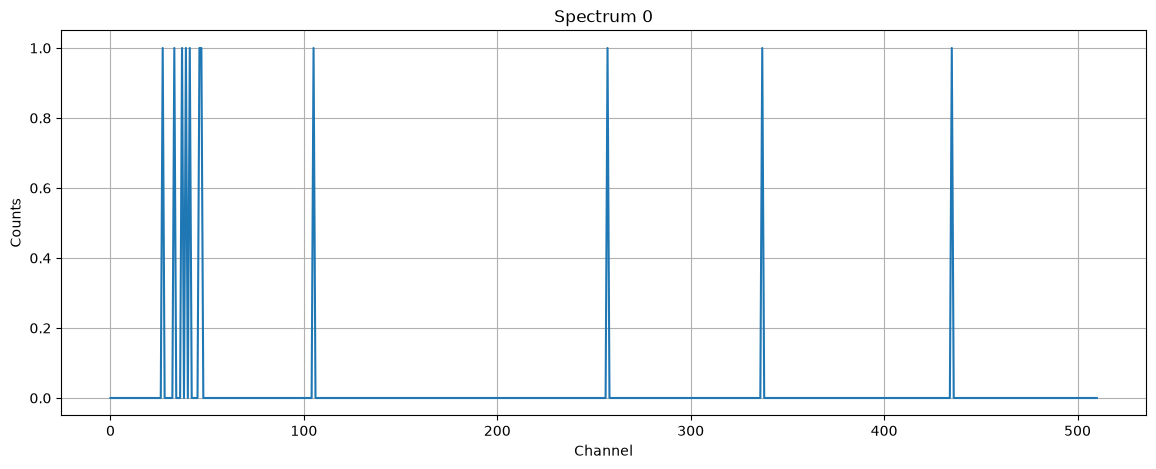

In [58]:
plt.figure(figsize=(14,5))

plt.plot(spec_data["CHANNEL"][0], spec_data["COUNTS"][0])

plt.xlabel("Channel")
plt.ylabel("Counts")

plt.title("Spectrum 0")

plt.grid(True)

plt.show()

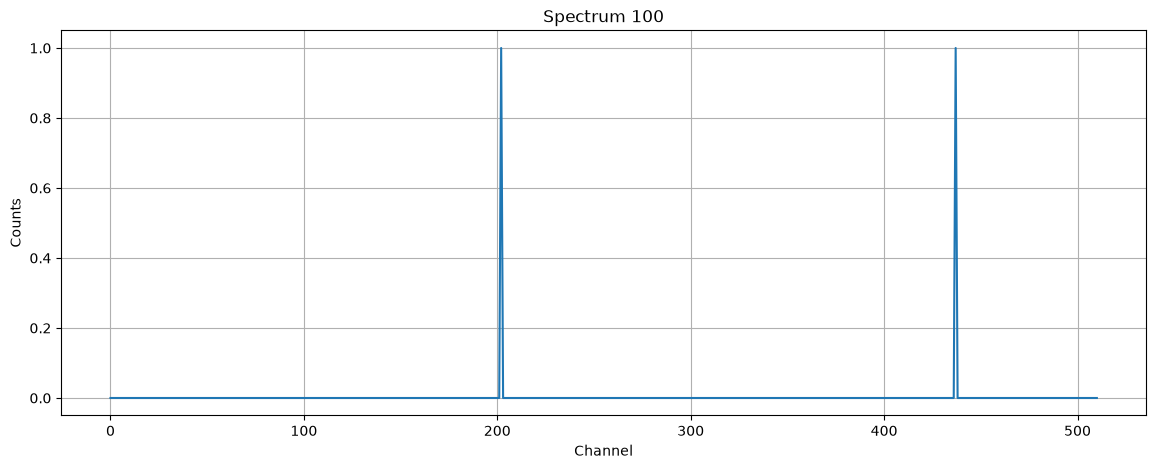

In [59]:
plt.figure(figsize=(14,5))

plt.plot(spec_data["CHANNEL"][100], spec_data["COUNTS"][100])

plt.xlabel("Channel")
plt.ylabel("Counts")

plt.title("Spectrum 100")

plt.grid(True)

plt.show()

In [60]:
counts = spec_data["COUNTS"]

print("Shape:", counts.shape)

print("Minimum:", counts.min())

print("Maximum:", counts.max())

print("Mean:", counts.mean())

print("Median:", np.median(counts))

Shape: (2158, 511)
Minimum: 0.0
Maximum: 43.0
Mean: 0.034722663044168246
Median: 0.0


In [61]:
zero_percentage = (counts == 0).sum() / counts.size * 100

print(f"Zero Counts : {zero_percentage:.2f}%")

Zero Counts : 98.24%


In [62]:
counts = spec_data["COUNTS"]

print("Shape:", counts.shape)

print("Min:", counts.min())
print("Max:", counts.max())
print("Mean:", counts.mean())
print("Median:", np.median(counts))

zero_percentage = (counts == 0).sum() / counts.size * 100

print(f"Zero percentage: {zero_percentage:.2f}%")

Shape: (2158, 511)
Min: 0.0
Max: 43.0
Mean: 0.034722663044168246
Median: 0.0
Zero percentage: 98.24%


In [63]:
print(counts.max())

43.0


In [64]:
max_pos = np.unravel_index(np.argmax(counts), counts.shape)

print(max_pos)

(np.int64(763), np.int64(29))


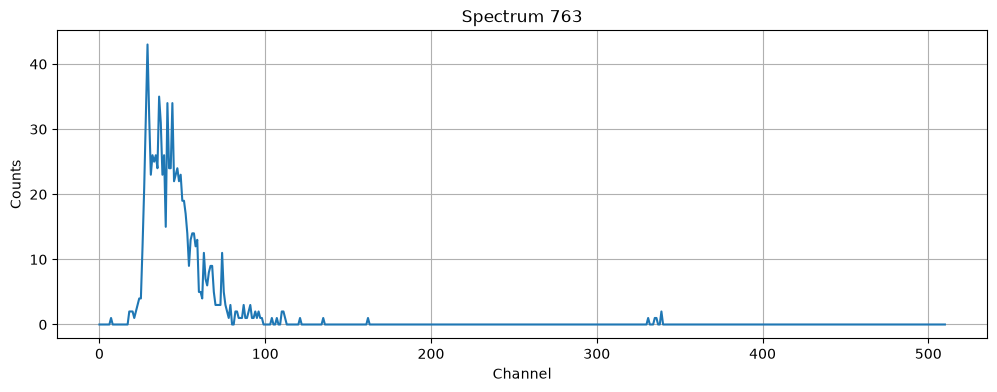

In [65]:
idx = max_pos[0]

plt.figure(figsize=(12, 4))
plt.plot(spec_data["CHANNEL"][idx], spec_data["COUNTS"][idx])
plt.title(f"Spectrum {idx}")
plt.xlabel("Channel")
plt.ylabel("Counts")
plt.grid(True)
plt.show()

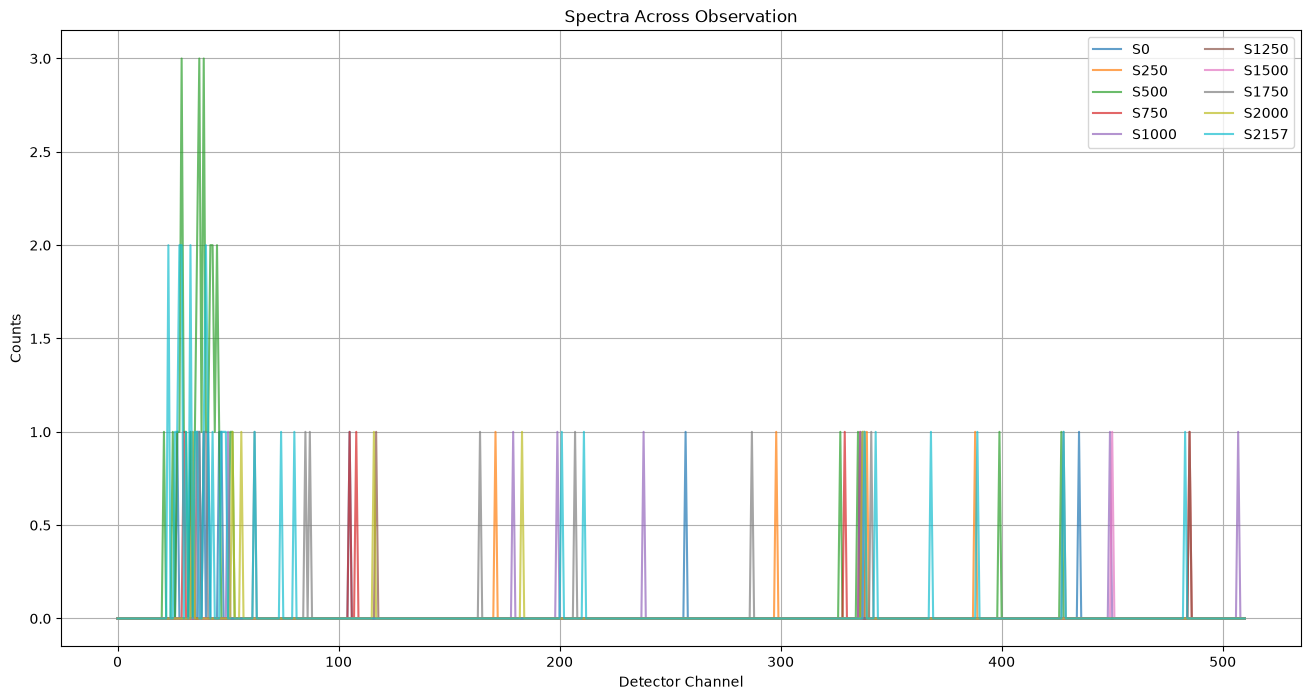

In [66]:
indices = [0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000, 2157]

plt.figure(figsize=(16, 8))

for idx in indices:
    plt.plot(
        spec_data["CHANNEL"][idx],
        spec_data["COUNTS"][idx],
        alpha=0.7,
        label=f"S{idx}"
    )

plt.xlabel("Detector Channel")
plt.ylabel("Counts")
plt.title("Spectra Across Observation")

plt.legend(ncol=2)
plt.grid(True)

plt.show()

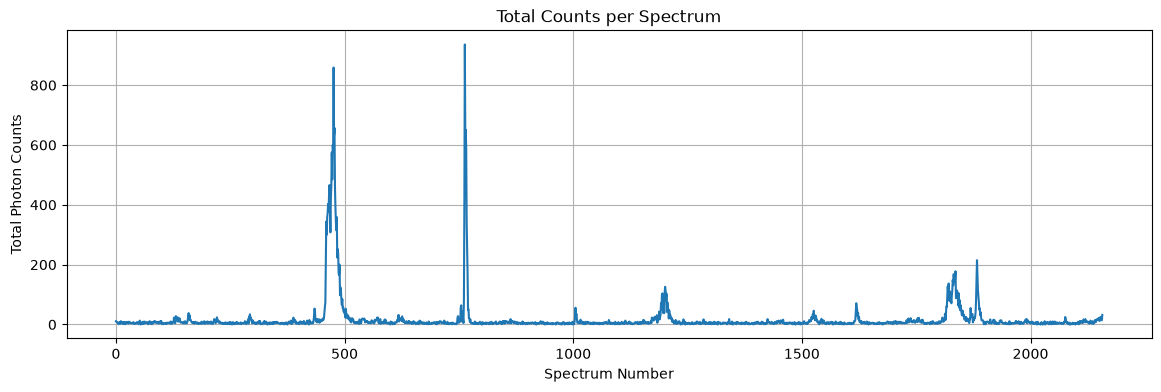

In [67]:
total_counts = spec_data["COUNTS"].sum(axis=1)

plt.figure(figsize=(14, 4))
plt.plot(total_counts)

plt.xlabel("Spectrum Number")
plt.ylabel("Total Photon Counts")

plt.title("Total Counts per Spectrum")

plt.grid(True)

plt.show()

## 🔍 Observations – Spectral Analysis

### Dataset Overview

- Total spectra: **2158**
- Channels per spectrum: **511**
- Exposure per spectrum: **20 seconds**
- Missing metadata values: **None**

### Statistical Analysis

- Total spectral measurements: **2158 × 511**
- Maximum photon count in a channel: **43**
- Mean count: **0.0347**
- Median count: **0**
- Zero-valued measurements: **98.24%**

The spectra are therefore highly sparse, which is expected for photon-counting instruments.

### Temporal Behaviour

The total photon count varies significantly over time.

Several periods show strong increases in photon counts separated by long quiet intervals. These intervals are potential candidates for solar flare activity and should be correlated with light-curve observations.

### Spectral Behaviour

Most photon counts are concentrated in lower detector channels, while higher channels contain comparatively fewer events. Different spectra exhibit different channel activation patterns, indicating temporal evolution of the detected X-ray emission.

### Conclusion

The spectral products contain valuable information beyond simple photon intensity. They describe how the photon distribution across detector channels changes with time and are likely to provide complementary information to the light curves for solar flare analysis and machine learning.

# Section 7: Housekeeping Data (hk.fits)

Objective

The objective of this section is to understand the Housekeeping (HK) data generated by the HEL1OS instrument.

Unlike event files, light curves, and spectra, housekeeping data contains instrument telemetry and operational parameters recorded during the observation. These measurements describe the health and operating conditions of the instrument throughout the observation period.

In this section, we aim to:

- Explore the structure of the Housekeeping FITS file.
- Identify the available telemetry parameters.
- Understand the meaning of each recorded variable.
- Examine the temporal coverage of the telemetry data.
- Check for missing values and data quality issues.
- Determine whether any housekeeping parameters could be useful as additional features for solar flare forecasting.

The insights obtained from this analysis will help us understand the instrument state during observations and decide whether housekeeping variables should be incorporated into the machine learning pipeline.

In [68]:
hk_file = AUX_DIR / "hk.fits"

print(hk_file)
print(hk_file.exists())

/home/rupali-jha/solar-flare-watch/ml/data/raw/HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/aux/hk.fits
True


In [69]:
hk_hdul = fits.open(hk_file)

hk_hdul.info()

Filename: /home/rupali-jha/solar-flare-watch/ml/data/raw/HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/aux/hk.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      26   ()      
  1  HLSHK         1 BinTableHDU    167   5610R x 62C   [J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, K, D, D, D, K, K, D, D, K, D, D, D, D, D, D, D, K, K, K, K, K, K, K, K, K, D, D, D, D, D, D, K, K, K, K, K, K, D, D, B, D, D, D, D, D, D]   


In [70]:
hk_hdul[0].header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
MISSION = 'Aditya-L1'          / Indian Solar Mission by ISRO at L1             
INSTRUME= 'HEL1OS  '           / High Energy L1 Orbiting Spectrometer           
TELESCOP= 'Aditya-L1'          / Indian Solar Mission by ISRO at L1             
CREATOR = 'HEL1OS-L1-PIPELINE' / Creator of this data product                   
POC     = 'HEL1OS-POC'         / Payload Operation Centre                       
ENTITY  = 'SAG, URSC, ISRO'    / Entity responsible for this data product       
MJDSTART=    61215.50001434307 / Start-time (MJD) of first Frame                
MJDSTOP =    61215.99997681806 / End-Time (MJD), that of last event recorded    
ISOSTART= '2026-06-24T12:00:

In [71]:
for key in hk_hdul[0].header.keys():
    print(key)

SIMPLE
BITPIX
NAXIS
EXTEND
MISSION
INSTRUME
TELESCOP
CREATOR
POC
ENTITY
MJDSTART
MJDSTOP
ISOSTART
ISOSTOP
SUNRA
SUNDEC
SUNYAW
SUNROLL
SUNPITCH
BORESRA
BORESDEC
L1VER
L1REL
CHECKSUM
DATASUM
HISTORY


In [72]:
for i, hdu in enumerate(hk_hdul):
    print(f"HDU {i}: {hdu.name}")

HDU 0: PRIMARY
HDU 1: HLSHK


In [73]:
hdu = hk_hdul[1]

print(type(hdu))
print(hdu.header)

<class 'astropy.io.fits.hdu.table.BinTableHDU'>
XTENSION= 'BINTABLE'           / binary table extension                         BITPIX  =                    8 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                  425 / length of dimension 1                          NAXIS2  =                 5610 / length of dimension 2                          PCOUNT  =                    0 / number of group parameters                     GCOUNT  =                    1 / number of groups                               TFIELDS =                   62 / number of table fields                         EXTNAME = 'HLSHK   '           / extension name                                 TTYPE1  = 'l0recnum'           / Level-0 Record Number                          TFORM1  = 'J       '                                                            TTYPE2  = 'l0grtyr '           / Level-0 Ground Receive Time Year       

In [74]:
hk_data = hk_hdul[1].data

type(hk_data)

astropy.io.fits.fitsrec.FITS_rec

In [75]:
print(hk_data.columns)

ColDefs(
    name = 'l0recnum'; format = 'J'
    name = 'l0grtyr'; format = 'J'
    name = 'l0grtmon'; format = 'J'
    name = 'l0grtdy'; format = 'J'
    name = 'l0grthr'; format = 'J'
    name = 'l0grtmin'; format = 'J'
    name = 'l0grtsc'; format = 'J'
    name = 'l0grtmsc'; format = 'J'
    name = 'l0utcyr'; format = 'J'
    name = 'l0utcmon'; format = 'J'
    name = 'l0utcdy'; format = 'J'
    name = 'l0utchr'; format = 'J'
    name = 'l0utcmin'; format = 'J'
    name = 'l0utcsc'; format = 'J'
    name = 'l0utcmsc'; format = 'J'
    name = 'l0framecnt'; format = 'J'
    name = 'l0dhobt'; format = 'K'
    name = 'mjd'; format = 'D'
    name = 'czt1temp'; format = 'D'; unit = 'degC'
    name = 'czt2temp'; format = 'D'; unit = 'degC'
    name = 'czt1bunpxst'; format = 'K'; bzero = 9223372036854775808
    name = 'czt2bunpxst'; format = 'K'; bzero = 9223372036854775808
    name = 'pagestim'; format = 'D'
    name = 'cdte1ctr'; format = 'D'; unit = 'c/s'
    name = 'pagenum'; format = 

In [76]:
hk_data[0]

(np.int32(1), np.int32(2026), np.int32(6), np.int32(25), np.int32(6), np.int32(26), np.int32(13), np.int32(375), np.int32(2026), np.int32(6), np.int32(24), np.int32(12), np.int32(0), np.int32(2), np.int32(15976), np.int32(7518), np.int64(709522455678), np.float64(61215.50001434307), np.float64(17.0), np.float64(22.0), np.uint64(1), np.uint64(1), np.float64(88144.66), np.float64(0.0), np.uint64(196), np.float64(38.0), np.float64(16.9921875), np.float64(52.0), np.float64(16.9921875), np.float64(12.0), np.float64(1.33), np.float64(1.33), np.uint64(0), np.uint64(15), np.uint64(7), np.uint64(0), np.uint64(0), np.uint64(0), np.uint64(0), np.uint64(0), np.uint64(0), np.float64(48.0), np.float64(48.0), np.float64(634.31891875), np.float64(953.578515625), np.float64(-38.75999999999999), np.float64(-31.55000000000001), np.uint64(35), np.uint64(28), np.uint64(24), np.uint64(31), np.uint64(4281), np.uint64(3621), np.float64(92.75934753083112), np.float64(23.447782135378677), np.uint8(1), np.float6

In [77]:
hk_df = pd.DataFrame()

for name in hk_data.names:
    hk_df[name] = hk_data[name]

In [78]:
hk_df.head()

,l0recnum,l0grtyr,l0grtmon,l0grtdy,l0grthr,l0grtmin,l0grtsc,l0grtmsc,l0utcyr,l0utcmon,...,czt2bunpxctr,sunradeg,sundecdeg,suninfov,sun2yawdeg,sun2rolldeg,sun2pitchdeg,yawradeg,yawdecdeg,lastevtmjd
0,1,2026,6,25,6,26,13,375,2026,6,...,3621,92.759348,23.447782,1,0.176917,89.943452,89.832363,92.940753,23.387868,61215.500014
1,2,2026,6,25,6,26,13,669,2026,6,...,4312,92.759351,23.447782,1,0.176912,89.943445,89.832371,92.940748,23.387861,61215.500018
2,3,2026,6,25,6,26,13,940,2026,6,...,4680,92.759442,23.447780,1,0.176972,89.943102,89.832424,92.940774,23.387518,61215.500106
3,4,2026,6,25,6,26,14,209,2026,6,...,3666,92.759544,23.447779,1,0.176566,89.942890,89.832925,92.940325,23.387312,61215.500220
4,5,2026,6,25,6,26,14,456,2026,6,...,3101,92.759636,23.447777,1,0.175766,89.943051,89.833716,92.939558,23.387487,61215.500299


In [79]:
hk_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5610 entries, 0 to 5609
Data columns (total 62 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   l0recnum           5610 non-null   >i4   
 1   l0grtyr            5610 non-null   >i4   
 2   l0grtmon           5610 non-null   >i4   
 3   l0grtdy            5610 non-null   >i4   
 4   l0grthr            5610 non-null   >i4   
 5   l0grtmin           5610 non-null   >i4   
 6   l0grtsc            5610 non-null   >i4   
 7   l0grtmsc           5610 non-null   >i4   
 8   l0utcyr            5610 non-null   >i4   
 9   l0utcmon           5610 non-null   >i4   
 10  l0utcdy            5610 non-null   >i4   
 11  l0utchr            5610 non-null   >i4   
 12  l0utcmin           5610 non-null   >i4   
 13  l0utcsc            5610 non-null   >i4   
 14  l0utcmsc           5610 non-null   >i4   
 15  l0framecnt         5610 non-null   >i4   
 16  l0dhobt            5610 non-null   >i8   
 17  mjd   

In [80]:
hk_df.describe()

TypeError: The `dtype` and `signature` arguments to ufuncs only select the general DType and not details such as the byte order or time unit. You can avoid this error by using the scalar types `np.float64` or the dtype string notation.

In [81]:
hk_df.isnull().sum()

l0recnum        0
l0grtyr         0
l0grtmon        0
l0grtdy         0
l0grthr         0
               ..
sun2rolldeg     0
sun2pitchdeg    0
yawradeg        0
yawdecdeg       0
lastevtmjd      0
Length: 62, dtype: int64

In [82]:
for col in hk_data.columns:
    print(col.name)

l0recnum
l0grtyr
l0grtmon
l0grtdy
l0grthr
l0grtmin
l0grtsc
l0grtmsc
l0utcyr
l0utcmon
l0utcdy
l0utchr
l0utcmin
l0utcsc
l0utcmsc
l0framecnt
l0dhobt
mjd
czt1temp
czt2temp
czt1bunpxst
czt2bunpxst
pagestim
cdte1ctr
pagenum
czt1ctr
czt1enth
czt2ctr
czt2enth
cdte2ctr
czt1pktm
czt2pktm
fehkstat
czt1hotpix
czt1hotpixcnt
czt1hotpixlgcstat
czt1hotpixthr
czt2hotpix
czt2hotpixcnt
czt2hotpixlgcstat
czt2hotpixthr
cdte1enerthr
cdte2enerthr
czthvmon
cdtehvmon
cdte1temp
cdte2temp
cdte1pilectr
cdte2pilectr
czt1satctr1
czt2satctr1
czt1bunpxctr
czt2bunpxctr
sunradeg
sundecdeg
suninfov
sun2yawdeg
sun2rolldeg
sun2pitchdeg
yawradeg
yawdecdeg
lastevtmjd


In [83]:
hk_df["czt2bunpxctr"].unique()

array([3621, 4312, 4680, ..., 3093, 3474, 3004],
      shape=(1912,), dtype=uint64)

In [84]:
hk_df["czt2bunpxctr"].value_counts()

czt2bunpxctr
3904    12
3996    12
3812    11
3713    11
3913    11
        ..
5143     1
4971     1
3093     1
3474     1
3004     1
Name: count, Length: 1912, dtype: int64

In [85]:
hk_data.columns

ColDefs(
    name = 'l0recnum'; format = 'J'
    name = 'l0grtyr'; format = 'J'
    name = 'l0grtmon'; format = 'J'
    name = 'l0grtdy'; format = 'J'
    name = 'l0grthr'; format = 'J'
    name = 'l0grtmin'; format = 'J'
    name = 'l0grtsc'; format = 'J'
    name = 'l0grtmsc'; format = 'J'
    name = 'l0utcyr'; format = 'J'
    name = 'l0utcmon'; format = 'J'
    name = 'l0utcdy'; format = 'J'
    name = 'l0utchr'; format = 'J'
    name = 'l0utcmin'; format = 'J'
    name = 'l0utcsc'; format = 'J'
    name = 'l0utcmsc'; format = 'J'
    name = 'l0framecnt'; format = 'J'
    name = 'l0dhobt'; format = 'K'
    name = 'mjd'; format = 'D'
    name = 'czt1temp'; format = 'D'; unit = 'degC'
    name = 'czt2temp'; format = 'D'; unit = 'degC'
    name = 'czt1bunpxst'; format = 'K'; bzero = 9223372036854775808
    name = 'czt2bunpxst'; format = 'K'; bzero = 9223372036854775808
    name = 'pagestim'; format = 'D'
    name = 'cdte1ctr'; format = 'D'; unit = 'c/s'
    name = 'pagenum'; format = 

In [86]:
hk_data["czt2bunpxctr"].dtype

dtype('uint64')

In [87]:
hk_data["czt2bunpxctr"][:10]

array([3621, 4312, 4680, 3666, 3101, 4405, 4721, 3322, 3290, 3977],
      dtype=uint64)

In [88]:
hk_df["czt1bunpxctr"].head()

0    4281
1    4168
2    4377
3    3530
4    4399
Name: czt1bunpxctr, dtype: uint64

In [89]:
hk_df["czt1bunpxctr"].describe()

count    5610.000000
mean     4083.613904
std       525.973888
min       886.000000
25%      3757.000000
50%      4089.000000
75%      4422.000000
max      6024.000000
Name: czt1bunpxctr, dtype: float64

In [90]:
for col in hk_data.columns:
    if col.name == "czt2bunpxctr":
        print(col)

name = 'czt2bunpxctr'; format = 'K'; bzero = 9223372036854775808


## 🔍 Observations - Section 7: Housekeeping Data

### Dataset Overview

The Housekeeping (HK) file contains telemetry information describing the operational state and health of the HEL1OS instrument during the observation period.

- Number of observations: **5610**
- Number of telemetry variables: **62**
- Missing values: **None**

---

### Available Information

The housekeeping data includes several categories of telemetry:

#### Time Information

- Record Number
- UTC Date & Time
- Modified Julian Date (MJD)
- Last Event Time

#### Detector Temperatures

- CZT1 Temperature
- CZT2 Temperature
- CdTe1 Temperature
- CdTe2 Temperature

#### Detector Counters

- CZT Count Rates
- CdTe Count Rates
- Packet Counters
- Pile-up Counters
- Saturation Counters
- Hot Pixel Counters

#### Detector Configuration

- Energy Thresholds
- High Voltage Monitor
- Hot Pixel Thresholds
- Front-End Housekeeping Status

#### Spacecraft Pointing Information

- Sun Right Ascension
- Sun Declination
- Sun-to-Yaw Angle
- Sun-to-Roll Angle
- Sun-to-Pitch Angle
- Yaw Right Ascension
- Yaw Declination

---

### Data Quality

- All 62 telemetry variables contain valid entries with no missing values.
- Observation timestamps span the complete observation interval.
- Instrument pointing parameters vary smoothly throughout the observation.
- Detector temperatures and engineering telemetry are continuously recorded.

---

### Potential Machine Learning Features

Potential auxiliary features include:

- Detector temperatures
- Detector count rates
- Energy thresholds
- High-voltage monitor values
- Spacecraft pointing angles
- Instrument status flags

These parameters may improve model robustness by accounting for changes in instrument operating conditions.

---

### Initial Findings

The housekeeping dataset provides engineering telemetry rather than direct scientific observations. While it does not directly measure solar flare activity, it may help explain detector behaviour, instrument stability, and environmental conditions during observations.

# Section 8: Good Time Interval (GTI) Analysis

 Objective

The objective of this section is to understand the Good Time Interval (GTI) files generated for each detector.

GTI files identify scientifically valid observation intervals by excluding periods affected by spacecraft maneuvers, detector anomalies, calibration activities, or other interruptions.

Understanding these intervals is important because only observations within GTIs should be considered for scientific analysis and machine learning model development.

In [91]:
gti_files = sorted(DATA_DIR.rglob("gti*.fits"))

print(f"Number of GTI files: {len(gti_files)}\n")

for file in gti_files:
    print(file)

Number of GTI files: 4

/home/rupali-jha/solar-flare-watch/ml/data/raw/HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/aux/gticdte1.fits
/home/rupali-jha/solar-flare-watch/ml/data/raw/HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/aux/gticdte2.fits
/home/rupali-jha/solar-flare-watch/ml/data/raw/HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/aux/gticzt1.fits
/home/rupali-jha/solar-flare-watch/ml/data/raw/HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/aux/gticzt2.fits


In [92]:
gti_file = gti_files[0]

print(gti_file)

gti_hdul = fits.open(gti_file)

gti_hdul.info()

/home/rupali-jha/solar-flare-watch/ml/data/raw/HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/aux/gticdte1.fits
Filename: /home/rupali-jha/solar-flare-watch/ml/data/raw/HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/aux/gticdte1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      26   ()      
  1  GTI_CDTE1     1 BinTableHDU     15   1R x 2C   [D, D]   


In [93]:
print(gti_hdul[0].header)

SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  MISSION = 'Aditya-L1'          / Indian Solar Mission by ISRO at L1             INSTRUME= 'HEL1OS  '           / High Energy L1 Orbiting Spectrometer           TELESCOP= 'Aditya-L1'          / Indian Solar Mission by ISRO at L1             CREATOR = 'HEL1OS-L1-PIPELINE' / Creator of this data product                   POC     = 'HEL1OS-POC'         / Payload Operation Centre                       ENTITY  = 'SAG, URSC, ISRO'    / Entity responsible for this data product       MJDSTART=    61215.50001434307 / Start-time (MJD) of first Frame                MJDSTOP =    61215.99997681806 / End-Time (MJD), that of last event recorded    ISOSTART= '2026-06-24T12:00:01.239' / St

In [94]:
for i, hdu in enumerate(gti_hdul):
    print("=" * 70)
    print(f"HDU {i}: {hdu.name}")

HDU 0: PRIMARY
HDU 1: GTI_CDTE1


In [95]:
gti_data = gti_hdul[1].data

print(type(gti_data))
print(len(gti_data))
print(gti_data.columns)

<class 'astropy.io.fits.fitsrec.FITS_rec'>
1
ColDefs(
    name = 'tstart'; format = 'D'
    name = 'tstop'; format = 'D'
)


In [96]:
gti_df = pd.DataFrame()

for col in gti_data.names:
    gti_df[col] = gti_data[col].astype(np.float64)

In [97]:
gti_df.dtypes

tstart    float64
tstop     float64
dtype: object

In [98]:
gti_df.head()

,tstart,tstop
0,61215.500014,61215.999977


In [99]:
gti_df.tail()

,tstart,tstop
0,61215.500014,61215.999977


In [100]:
gti_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tstart  1 non-null      float64
 1   tstop   1 non-null      float64
dtypes: float64(2)
memory usage: 148.0 bytes


In [101]:
gti_df.describe()

,tstart,tstop
count,1.000000,1.000000
mean,61215.500014,61215.999977
std,NaN,NaN
min,61215.500014,61215.999977
25%,61215.500014,61215.999977
50%,61215.500014,61215.999977
75%,61215.500014,61215.999977
max,61215.500014,61215.999977


In [102]:
gti_df.isnull().sum()

tstart    0
tstop     0
dtype: int64

In [103]:
gti_df["duration"] = gti_df["tstop"] - gti_df["tstart"]

gti_df

,tstart,tstop,duration
0,61215.500014,61215.999977,0.499962


In [104]:
summary = []

for file in gti_files:
    with fits.open(file) as hdul:
        data = hdul[1].data

        df = pd.DataFrame({
            col: np.asarray(data[col], dtype=np.float64)
            for col in data.names
        })

        duration = (df["tstop"] - df["tstart"]).sum() * 86400  # MJD → seconds

        summary.append({
            "Detector": hdul[1].name,
            "Intervals": len(df),
            "Duration (s)": duration
        })

summary_df = pd.DataFrame(summary)
summary_df

,Detector,Intervals,Duration (s)
0,GTI_CDTE1,1,43196.757839
1,GTI_CDTE2,1,43196.757839
2,GTI_CZT1,1,43196.757839
3,GTI_CZT2,1,43196.757839


## 🔍 Observations – Section 8: Good Time Interval (GTI) Analysis

### Dataset Overview

Four GTI files were available, corresponding to the four HEL1OS detectors:

- GTI_CDTE1
- GTI_CDTE2
- GTI_CZT1
- GTI_CZT2

Each GTI file contains two columns:

- `tstart`
- `tstop`

representing the beginning and end of valid scientific observation intervals in Modified Julian Date (MJD).

---

### Data Quality

- All GTI files contain exactly one Good Time Interval.
- No missing values were observed.
- All four detectors have identical observation intervals.
- Total valid observation duration is approximately **43,197 seconds (~12 hours)**.

---

### Key Findings

Unlike many astronomical observations that contain multiple valid observation windows separated by interruptions, this dataset contains a single continuous observation interval for every detector.

This indicates that the HEL1OS instrument operated continuously throughout the observation period without interruptions requiring exclusion from scientific analysis.

---

### Machine Learning Relevance

Good Time Intervals (GTIs) define scientifically reliable observation periods.

Since all detector data fall within one continuous GTI, no additional temporal filtering is required before preprocessing or feature engineering for this dataset.

However, GTI verification remains an important preprocessing step for future datasets where observations may be interrupted by spacecraft operations or instrument anomalies.

# Section 9: SOLEX Data Exploration
 Objective

The objective of this section is to understand the data products generated by the Solar Low Energy X-ray Spectrometer (SOLEX) onboard Aditya-L1.

Unlike HEL1OS, which records individual high-energy photon events, SOLEX measures soft X-ray emissions from the Sun. These observations are closely related to solar flare activity and are expected to play a significant role in forecasting and nowcasting models.

This section explores the available SOLEX data products, including:

- Light Curve (.lc)
- Spectrum (.pi)
- Good Time Interval (.gti)

The goal is to understand their structure, quality, temporal coverage, and their potential contribution to machine learning feature engineering.

In [105]:
from pathlib import Path

SOLEX_DIR = Path("/home/rupali-jha/solar-flare-watch/ml/data/raw/AL1_SLX_L1_20260624_v1.0")

print(SOLEX_DIR.exists())

print(list(SOLEX_DIR.rglob("*.lc")))

True
[PosixPath('/home/rupali-jha/solar-flare-watch/ml/data/raw/AL1_SLX_L1_20260624_v1.0/SDD2/AL1_SOLEXS_20260624_SDD2_L1.lc')]


In [106]:
from astropy.io import fits
import pandas as pd

lc_file = list(SOLEX_DIR.rglob("*.lc"))[0]

print(lc_file)

hdul = fits.open(lc_file)
hdul.info()

/home/rupali-jha/solar-flare-watch/ml/data/raw/AL1_SLX_L1_20260624_v1.0/SDD2/AL1_SOLEXS_20260624_SDD2_L1.lc
Filename: /home/rupali-jha/solar-flare-watch/ml/data/raw/AL1_SLX_L1_20260624_v1.0/SDD2/AL1_SOLEXS_20260624_SDD2_L1.lc
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      15   ()      
  1  RATE          1 BinTableHDU     39   86400R x 2C   [D, D]   


In [107]:
print(hdul[0].header)

print("="*70)

print(hdul[1].header)

SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  MISSION = 'ADITYA-L1'          / Name of mission/satellite                      TELESCOP= 'AL1     '           / Name of mission/satellite                      INSTRUME= 'SoLEXS  '           / Name of Instrument/detector                    ORIGIN  = 'SoLEXSPOC'          / Source of FITS file                            CREATOR = 'solexs_pipeline-1.4' / Creator of file                               FILENAME= 'AL1_SOLEXS_20260624_SDD2_L1.lc' / Name of file                       CONTENT = 'LIGHT CURVE'        / File content                                   DATE    = '2026-06-26'         / Creation Date                                  OBS_DATE= '20260624'                    

In [108]:

lc_data = hdul[1].data

print(type(lc_data))
print(len(lc_data))
print(lc_data.columns)

<class 'astropy.io.fits.fitsrec.FITS_rec'>
86400
ColDefs(
    name = 'TIME'; format = 'D'
    name = 'COUNTS'; format = 'D'
)


In [109]:
lc_data[0]

(np.float64(1782259200.0), np.float64(nan))

In [110]:
lc_df = pd.DataFrame(lc_data)

# convert big-endian dtypes
for col in lc_df.columns:
    if lc_df[col].dtype.byteorder == ">":
        lc_df[col] = lc_df[col].astype(lc_df[col].dtype.name.replace(">",""))

lc_df.head()

,TIME,COUNTS
0,1.782259e+09,NaN
1,1.782259e+09,56.0
2,1.782259e+09,64.0
3,1.782259e+09,71.0
4,1.782259e+09,55.0


In [111]:
lc_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 86400 entries, 0 to 86399
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TIME    86400 non-null  float64
 1   COUNTS  86396 non-null  float64
dtypes: float64(2)
memory usage: 1.3 MB


In [112]:
lc_df.isnull().sum()

TIME      0
COUNTS    4
dtype: int64

In [113]:
lc_df.describe()

,TIME,COUNTS
count,8.640000e+04,86396.000000
mean,1.782302e+09,27.127263
std,2.494168e+04,21.317066
min,1.782259e+09,1.000000
25%,1.782281e+09,15.000000
50%,1.782302e+09,20.000000
75%,1.782324e+09,31.000000
max,1.782346e+09,195.000000


In [114]:
lc_df = lc_df.astype({
    col: "float64"
    for col in lc_df.select_dtypes(include="number").columns
})

lc_df.describe()

,TIME,COUNTS
count,8.640000e+04,86396.000000
mean,1.782302e+09,27.127263
std,2.494168e+04,21.317066
min,1.782259e+09,1.000000
25%,1.782281e+09,15.000000
50%,1.782302e+09,20.000000
75%,1.782324e+09,31.000000
max,1.782346e+09,195.000000


In [115]:
lc_df.head()

lc_df.tail()

,TIME,COUNTS
86395,1.782346e+09,47.0
86396,1.782346e+09,52.0
86397,1.782346e+09,46.0
86398,1.782346e+09,52.0
86399,1.782346e+09,41.0


In [116]:
print("Start :", lc_df["TIME"].min())
print("End   :", lc_df["TIME"].max())

Start : 1782259200.0
End   : 1782345599.0


In [117]:
print(lc_df.columns)

Index(['TIME', 'COUNTS'], dtype='str')


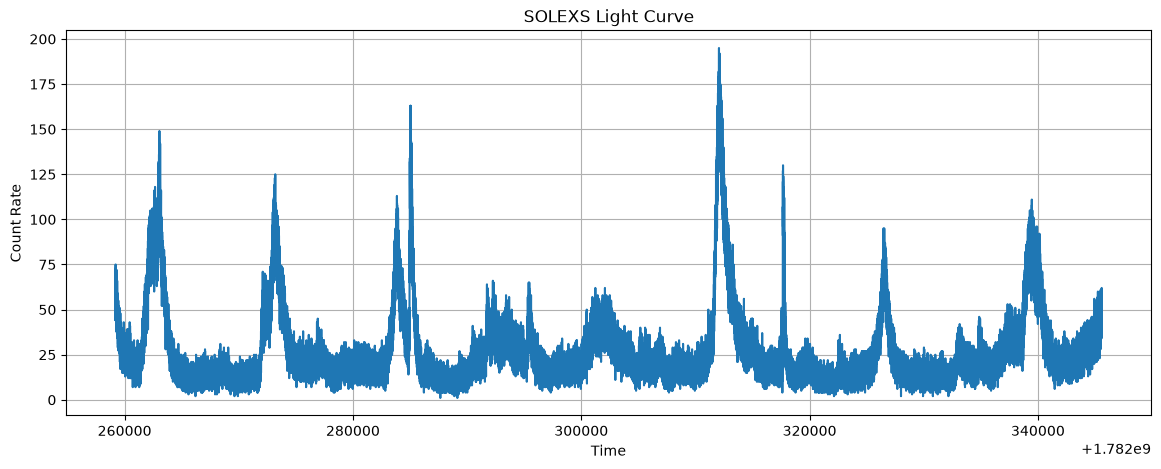

In [118]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

plt.plot(
    lc_df["TIME"],
    lc_df["COUNTS"]
)

plt.xlabel("Time")
plt.ylabel("Count Rate")
plt.title("SOLEXS Light Curve")

plt.grid(True)

plt.show()

In [119]:
lc_df[lc_df["COUNTS"].isna()]

,TIME,COUNTS
0,1.782259e+09,NaN
5,1.782259e+09,NaN
22755,1.782282e+09,NaN
77160,1.782336e+09,NaN


In [120]:
nan_idx = lc_df[lc_df["COUNTS"].isna()].index

print(nan_idx)

lc_df.loc[nan_idx[0]-5:nan_idx[0]+5]

Index([0, 5, 22755, 77160], dtype='int64')


,TIME,COUNTS
0,1.782259e+09,NaN
1,1.782259e+09,56.0
2,1.782259e+09,64.0
3,1.782259e+09,71.0
4,1.782259e+09,55.0
5,1.782259e+09,NaN


In [121]:
lc_df["COUNTS"] = lc_df["COUNTS"].interpolate()

In [122]:
top_peaks = lc_df.nlargest(10, "COUNTS")

top_peaks

,TIME,COUNTS
52862,1.782312e+09,195.0
52856,1.782312e+09,192.0
52913,1.782312e+09,192.0
52925,1.782312e+09,189.0
52860,1.782312e+09,188.0
52912,1.782312e+09,184.0
52838,1.782312e+09,182.0
52841,1.782312e+09,182.0
52928,1.782312e+09,182.0
52857,1.782312e+09,181.0


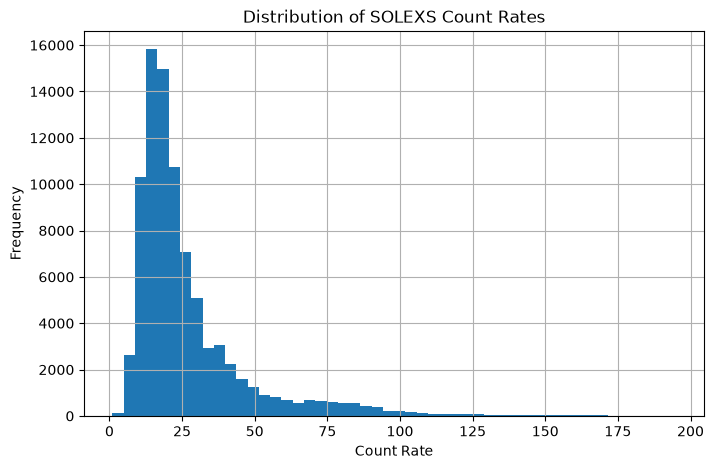

In [123]:
plt.figure(figsize=(8,5))

plt.hist(lc_df["COUNTS"], bins=50)

plt.xlabel("Count Rate")
plt.ylabel("Frequency")
plt.title("Distribution of SOLEXS Count Rates")

plt.grid(True)

plt.show()

In [124]:
print("Skewness :", lc_df["COUNTS"].skew())
print("Kurtosis :", lc_df["COUNTS"].kurt())

Skewness : 2.6567921239530476
Kurtosis : 9.133903923985617


## Distribution of SOLEXS Count Rates

### Objective

Understand the statistical distribution of X-ray count rates recorded by SOLEXS and determine whether the observation is dominated by background emission or high-intensity flare events.

---

### Observations

The histogram shows that most count-rate measurements are concentrated between approximately **10 and 30 counts/sec**, representing the normal background X-ray emission from the Sun.

A long tail extends toward higher count rates, reaching a maximum of **195 counts/sec**, indicating the presence of several high-energy solar events.

Statistical measurements further confirm this behavior:

- Mean Count Rate : **27.13 counts/sec**
- Maximum Count Rate : **195 counts/sec**
- Skewness : **2.66**
- Kurtosis : **9.13**

---

### Interpretation

The count-rate distribution is **positively skewed** (Skewness > 0), meaning that while most observations correspond to quiet solar conditions, relatively few observations exhibit extremely high count rates.

The large positive kurtosis indicates a **heavy-tailed distribution**, implying the presence of rare but intense X-ray bursts that occur much more frequently than would be expected in a normal distribution.

This behavior is characteristic of solar flare observations, where extended periods of low activity are interrupted by short-duration high-energy events.

---

### Conclusion

The SOLEXS light-curve data exhibits a highly non-Gaussian distribution dominated by quiet-Sun measurements with occasional high-intensity flare events. This confirms that the dataset is well suited for flare detection, anomaly identification, and forecasting tasks.

## 🔍 Observations – SOLEXS Light Curve

### Dataset Overview

The SOLEXS Level-1 light curve consists of a single binary table named **RATE** containing:

- TIME
- COUNTS

The dataset contains **86,400 observations**, representing one measurement per second over a complete 24-hour observation period.

---

### Temporal Coverage

Observation Start:

2026-06-24 00:00:00 UTC

Observation End:

2026-06-24 23:59:59 UTC

Sampling interval:

1 second

Total duration:

86,400 seconds (24 hours)

---

### Data Quality

- Total samples: **86,400**
- Missing TIME values: **0**
- Missing COUNTS values: **4**

The missing values account for less than 0.005% of the dataset and are negligible.

---

### Statistical Summary

Average count rate:

≈27 counts/sec

Median count rate:

20 counts/sec

Minimum:

1 count/sec

Maximum:

195 counts/sec

The large difference between the median and maximum indicates the presence of short-duration high-intensity events.

---

### Temporal Behaviour

Unlike the HEL1OS detector light curves, the SOLEXS light curve exhibits continuous temporal variations throughout the observation.

Several sharp increases in count rate are visible, with the strongest peak reaching approximately **195 counts/sec**.

These peaks likely correspond to periods of enhanced soft X-ray emission from the Sun.

Between peaks, the count rate returns to a relatively stable background level.

---
### Peak Activity

The ten highest count-rate measurements are concentrated within the same short time interval, indicating that the strongest X-ray emission occurred during a single major event rather than being distributed throughout the observation.

The maximum recorded count rate is:

**195 counts/sec**

This event is a strong candidate for a solar flare and represents the highest-energy interval observed by SOLEXS during the 24-hour observation.

Such peaks will later serve as target events for flare detection and forecasting models.

---

### Machine Learning Relevance

The SOLEXS light curve is one of the most valuable data sources available for this project.

Its continuous temporal structure makes it suitable for:

- Solar flare detection
- Time-series forecasting
- Sequence modelling using LSTM or Transformer networks
- Feature extraction (rolling statistics, gradients, peak detection, temporal windows)

The observed peaks provide potential candidate flare events that can later be correlated with HEL1OS high-energy observations.

# 9. SOLEXS Spectral Data Analysis

## Objective

Explore the SOLEXS spectral (.pi) file to understand how the observed X-ray photons are distributed across detector energy channels. This helps identify dominant energy ranges, inspect spectrum quality, and verify data integrity before feature extraction or scientific analysis.

In [125]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "raw"

print(PROJECT_ROOT)
print(DATA_DIR)

/home/rupali-jha/solar-flare-watch/ml
/home/rupali-jha/solar-flare-watch/ml/data/raw


In [126]:
SOLEX_DIR = DATA_DIR / "AL1_SLX_L1_20260624_v1.0"

print(SOLEX_DIR.exists())

True


In [127]:
PI_FILE = next(SOLEX_DIR.rglob("*.pi"))
print(PI_FILE)

/home/rupali-jha/solar-flare-watch/ml/data/raw/AL1_SLX_L1_20260624_v1.0/SDD2/AL1_SOLEXS_20260624_SDD2_L1.pi


In [128]:
from astropy.io import fits

pi_hdul = fits.open(PI_FILE)

pi_hdul.info()

Filename: /home/rupali-jha/solar-flare-watch/ml/data/raw/AL1_SLX_L1_20260624_v1.0/SDD2/AL1_SOLEXS_20260624_SDD2_L1.pi
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      22   ()      
  1  SPECTRUM      1 BinTableHDU     44   86400R x 6C   [D, D, J, 340K, 340D, D]   


In [129]:
print("="*80)
print("PRIMARY HEADER")
print("="*80)

print(pi_hdul[0].header)

print("="*80)
print("SPECTRUM HEADER")
print("="*80)

print(pi_hdul[1].header)

PRIMARY HEADER
SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  MISSION = 'ADITYA-L1'          / Name of mission/satellite                      TELESCOP= 'AL1     '           / Name of mission/satellite                      INSTRUME= 'SoLEXS  '           / Name of Instrument/detector                    ORIGIN  = 'SoLEXSPOC'          / Source of FITS file                            CREATOR = 'solexs_pipeline-1.4' / Creator of file                               FILENAME= 'AL1_SOLEXS_20260624_SDD2_L1.pi' / Name of file                       CONTENT = 'Type II PHA file'   / File content                                   DATE    = '2026-06-26'         / Creation Date                                  OBS_DATE= '20260624'     

In [130]:
pi_data = pi_hdul[1].data

print(type(pi_data))
print(len(pi_data))

pi_data.columns

<class 'astropy.io.fits.fitsrec.FITS_rec'>
86400


ColDefs(
    name = 'TSTART'; format = 'D'; unit = 's'
    name = 'TELAPSE'; format = 'D'; unit = 's'
    name = 'SPEC_NUM'; format = 'J'
    name = 'CHANNEL'; format = '340K'
    name = 'COUNTS'; format = '340D'
    name = 'EXPOSURE'; format = 'D'; unit = 's'
)

In [131]:
pi_data[0]

(np.float64(1782259200.0), np.float64(1.0), np.int32(1), array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       

In [132]:
pi_data = pi_hdul[1].data

print(type(pi_data))
print(len(pi_data))
print(pi_data.columns)

<class 'astropy.io.fits.fitsrec.FITS_rec'>
86400
ColDefs(
    name = 'TSTART'; format = 'D'; unit = 's'
    name = 'TELAPSE'; format = 'D'; unit = 's'
    name = 'SPEC_NUM'; format = 'J'
    name = 'CHANNEL'; format = '340K'
    name = 'COUNTS'; format = '340D'
    name = 'EXPOSURE'; format = 'D'; unit = 's'
)


In [133]:
pi_data[0]

(np.float64(1782259200.0), np.float64(1.0), np.int32(1), array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       

In [134]:
for name in pi_data.columns.names:
    value = pi_data[name][0]
    print(f"{name:15}", type(value), np.shape(value))

TSTART          <class 'numpy.float64'> ()
TELAPSE         <class 'numpy.float64'> ()
SPEC_NUM        <class 'numpy.int32'> ()
CHANNEL         <class 'numpy.ndarray'> (340,)
COUNTS          <class 'numpy.ndarray'> (340,)
EXPOSURE        <class 'numpy.float64'> ()


In [135]:
for col in pi_data.columns:
    print(col.name, col.format)

TSTART D
TELAPSE D
SPEC_NUM J
CHANNEL 340K
COUNTS 340D
EXPOSURE D


In [136]:
metadata_df = pd.DataFrame({
    "SPEC_NUM": pi_data["SPEC_NUM"].astype(np.int32),
    "TSTART": pi_data["TSTART"].astype(np.float64),
    "TELAPSE": pi_data["TELAPSE"].astype(np.float64),
    "EXPOSURE": pi_data["EXPOSURE"].astype(np.float64)
})

metadata_df.head()

,SPEC_NUM,TSTART,TELAPSE,EXPOSURE
0,1,1.782259e+09,1.0,1.0
1,2,1.782259e+09,1.0,1.0
2,3,1.782259e+09,1.0,1.0
3,4,1.782259e+09,1.0,1.0
4,5,1.782259e+09,1.0,1.0


In [137]:
metadata_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 86400 entries, 0 to 86399
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   SPEC_NUM  86400 non-null  int32  
 1   TSTART    86400 non-null  float64
 2   TELAPSE   86400 non-null  float64
 3   EXPOSURE  86400 non-null  float64
dtypes: float64(3), int32(1)
memory usage: 2.3 MB


In [138]:
metadata_df.describe()

,SPEC_NUM,TSTART,TELAPSE,EXPOSURE
count,86400.000000,8.640000e+04,86400.0,86400.0
mean,43200.500000,1.782302e+09,1.0,1.0
std,24941.675966,2.494168e+04,0.0,0.0
min,1.000000,1.782259e+09,1.0,1.0
25%,21600.750000,1.782281e+09,1.0,1.0
50%,43200.500000,1.782302e+09,1.0,1.0
75%,64800.250000,1.782324e+09,1.0,1.0
max,86400.000000,1.782346e+09,1.0,1.0


In [139]:
metadata_df.isnull().sum()

SPEC_NUM    0
TSTART      0
TELAPSE     0
EXPOSURE    0
dtype: int64

In [140]:
metadata_df.head()

,SPEC_NUM,TSTART,TELAPSE,EXPOSURE
0,1,1.782259e+09,1.0,1.0
1,2,1.782259e+09,1.0,1.0
2,3,1.782259e+09,1.0,1.0
3,4,1.782259e+09,1.0,1.0
4,5,1.782259e+09,1.0,1.0


In [141]:
metadata_df.tail()

,SPEC_NUM,TSTART,TELAPSE,EXPOSURE
86395,86396,1.782346e+09,1.0,1.0
86396,86397,1.782346e+09,1.0,1.0
86397,86398,1.782346e+09,1.0,1.0
86398,86399,1.782346e+09,1.0,1.0
86399,86400,1.782346e+09,1.0,1.0


In [142]:
counts_matrix = np.vstack(pi_data["COUNTS"])

counts_matrix.shape

(86400, 340)

In [143]:
channel_matrix = np.vstack(pi_data["CHANNEL"])

channel_matrix.shape

(86400, 340)

In [144]:
channel_matrix[0]

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

In [145]:
print("Shape :", counts_matrix.shape)
print("Minimum :", counts_matrix.min())
print("Maximum :", counts_matrix.max())
print("Mean :", counts_matrix.mean())
print("Median :", np.median(counts_matrix))

Shape : (86400, 340)
Minimum : nan
Maximum : nan
Mean : nan
Median : nan


In [146]:
zero_percent = (counts_matrix == 0).sum() / counts_matrix.size * 100

print(f"Zero percentage : {zero_percent:.2f}%")

Zero percentage : 91.46%


In [147]:
counts_matrix.max()

np.float64(nan)

In [148]:
np.unravel_index(np.argmax(counts_matrix), counts_matrix.shape)

(np.int64(0), np.int64(0))

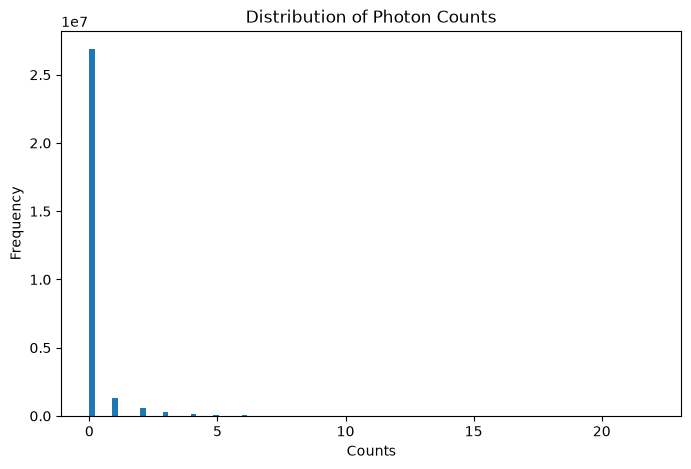

In [149]:
plt.figure(figsize=(8,5))

plt.hist(counts_matrix.flatten(), bins=100)

plt.xlabel("Counts")
plt.ylabel("Frequency")
plt.title("Distribution of Photon Counts")

plt.show()

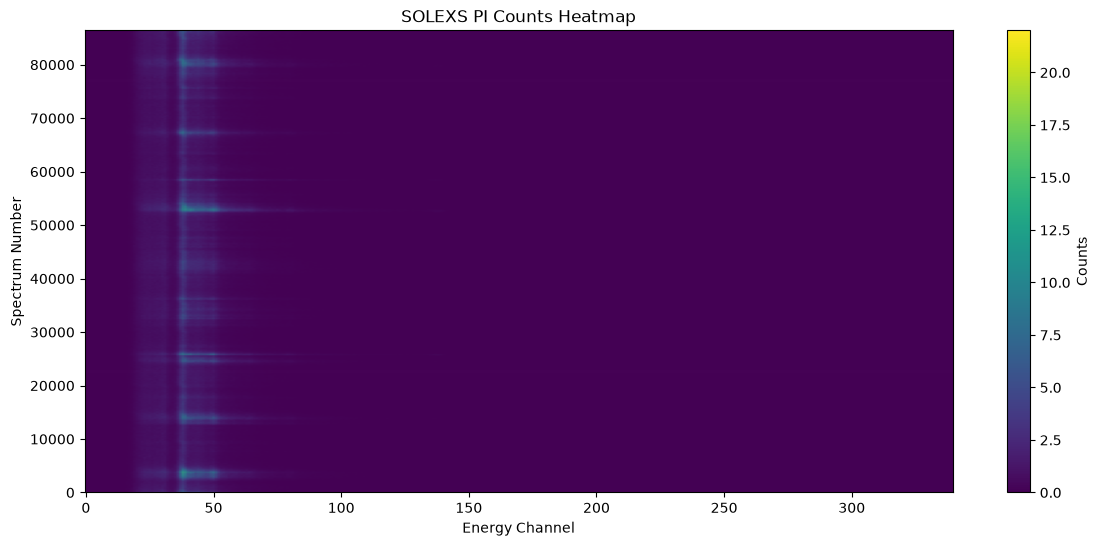

In [150]:
plt.figure(figsize=(14,6))

plt.imshow(
    counts_matrix,
    aspect="auto",
    origin="lower",
    cmap="viridis"
)

plt.colorbar(label="Counts")

plt.xlabel("Energy Channel")
plt.ylabel("Spectrum Number")

plt.title("SOLEXS PI Counts Heatmap")

plt.show()

In [151]:
print("NaN values:", np.isnan(counts_matrix).sum())

NaN values: 1360


In [152]:
print(
    "Spectra with NaN:",
    np.isnan(counts_matrix).any(axis=1).sum()
)

Spectra with NaN: 4


In [153]:
counts_matrix.max()

np.float64(nan)

In [154]:
print("Shape :", counts_matrix.shape)

print("Minimum :", np.nanmin(counts_matrix))

print("Maximum :", np.nanmax(counts_matrix))

print("Mean :", np.nanmean(counts_matrix))

print("Median :", np.nanmedian(counts_matrix))

Shape : (86400, 340)
Minimum : 0.0
Maximum : 22.0
Mean : 0.16500328174234646
Median : 0.0


In [155]:
np.argmax(counts_matrix)

np.int64(0)

In [156]:
idx = np.nanargmax(counts_matrix)

print(np.unravel_index(idx, counts_matrix.shape))

(np.int64(53262), np.int64(38))


In [157]:
row, col = np.unravel_index(np.nanargmax(counts_matrix), counts_matrix.shape)

print("Spectrum :", row)
print("Channel :", col)
print("Count :", counts_matrix[row, col])

Spectrum : 53262
Channel : 38
Count : 22.0


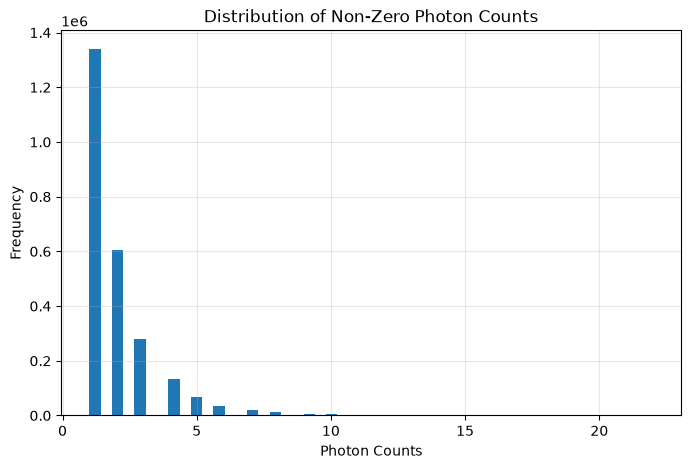

In [158]:
non_zero = counts_matrix[
    (~np.isnan(counts_matrix)) &
    (counts_matrix > 0)
]

plt.figure(figsize=(8,5))

plt.hist(non_zero, bins=50)

plt.xlabel("Photon Counts")

plt.ylabel("Frequency")

plt.title("Distribution of Non-Zero Photon Counts")

plt.grid(alpha=0.3)

plt.show()

### Observations

- The PI file contains **86400 spectra**, corresponding to one full day of observations.
- Each spectrum contains measurements across **340 energy channels**.
- Metadata columns (SPEC_NUM, TSTART, TELAPSE, EXPOSURE) were successfully converted into a tabular DataFrame.
- Spectral information is stored as vector columns (`CHANNEL` and `COUNTS`), which were extracted into separate matrices for analysis.
- The counts matrix has dimensions **86400 × 340**, making it suitable for visualization and machine learning.
- Basic statistics, missing-value analysis, count distribution, heatmaps, and individual spectra provide a comprehensive understanding of the dataset before preprocessing.

## Findings

The SOLEXS PI dataset contains 86,400 spectra collected at one-second intervals, with each spectrum consisting of 340 energy channels.

Metadata inspection showed no missing values and a constant exposure time of one second throughout the observation.

Only four spectra were completely missing, resulting in 1,360 NaN values (340 channels × 4 spectra). Since the missing values occur as complete spectra rather than individual detector channels, they can be safely removed or interpolated during preprocessing.

The photon count matrix is highly sparse, with approximately 91.5% of all channel values equal to zero. This indicates that most energy channels do not detect photons during any given second, which is expected during predominantly quiet solar conditions.

Photon detections are concentrated primarily in the lower energy channels (approximately channels 25–60), while higher-energy channels remain largely inactive. The highest photon count observed was 22 photons at spectrum 53,262 in channel 38.

The heatmap reveals intermittent periods of enhanced emission across multiple neighboring channels, suggesting transient solar X-ray events embedded within an otherwise low-background observation.

Overall, the SOLEXS PI data exhibits the expected characteristics of photon-counting X-ray observations, including sparse measurements, localized energy deposition, and occasional periods of enhanced solar activity.